# ISO 20414:2020 — Test 15: Social Influence on Exit Choice

A room of size 10 m x 15 m with two 1 m exits on the 15 m walls of the room (ISO 20414:2020 Figure 11). In Scenario 1, only two agents, equidistant to both exits, in the room and is free to choose between exits 1 and 2 (both exit weights are 50%). After statistics harvested for exit choice through several runs, Scenario 2 is run which inserts an additional occupant who is deterministically assigned to Exit 2.  Test is run several times again. Expected result is that the usage of Exit 2 is increased in scenario 2 for occupant 1.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 14 July 2026, 12:43 CEST


In [2]:
from pathlib import Path
import logging
logging.basicConfig(level=logging.WARNING, force=True)
logging.getLogger().setLevel(logging.WARNING)
#logging.getLogger("jupedsim_scenarios").setLevel(logging.WARNING)
#logging.getLogger("jupedsim").setLevel(logging.WARNING)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from jupedsim_scenarios import load_scenario, run_scenario, run_sweep

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load and Run

In [4]:
%%capture
SCENARIO_ZIP_1 = Path("scenario_files") / "Iso-15-social-influence-1.zip"
scenario_1 = load_scenario(str(SCENARIO_ZIP_1))
result_1 = run_scenario(scenario_1, seed=42)

In [5]:
print(scenario_1.summary())
walkable_1 = scenario_1.walkable_polygon

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/iso/scenario_files/Iso-15-social-influence-1.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         2
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~2
    jps-distributions_0: 2 agents


In [6]:
%%capture
SCENARIO_ZIP_2 = Path("scenario_files") / "Iso-15-social-influence-2.zip"
scenario_2 = load_scenario(str(SCENARIO_ZIP_2))
result_2 = run_scenario(scenario_2, seed=42)

In [7]:
print(scenario_2.summary())
walkable_2 = scenario_2.walkable_polygon

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/iso/scenario_files/Iso-15-social-influence-2.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         2
  Distributions: 2
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~3
    jps-distributions_0: 2 agents
    jps-distributions_1: 1 agents


In [8]:
def count_exit_choices(scenario, seeds, workers=4, track=None):
    sweep = run_sweep(scenario, seeds=seeds, workers=workers)
    exit_1_count = 0
    exit_2_count = 0
    unknown_count = 0
    rows = []

    for trial in sweep.trials:
        seed = trial.seed
        result = trial.result
        df_1 = result.trajectory_dataframe()

        if track == "behind":
            initial = df_1[df_1["frame"] == df_1["frame"].min()]
            tracked_ids = initial[initial["y"] < 1.5]["id"].tolist()
            final_rows = [
                df_1[df_1["id"] == agent_id].sort_values("frame").iloc[-1]
                for agent_id in tracked_ids
            ]
        elif track == "front":
            initial = df_1[df_1["frame"] == df_1["frame"].min()]
            tracked_ids = initial[initial["y"] >= 1.5]["id"].tolist()
            final_rows = [
                df_1[df_1["id"] == agent_id].sort_values("frame").iloc[-1]
                for agent_id in tracked_ids
            ]
        else:
            final_rows = [df_1.sort_values("frame").iloc[-1]]

        for last in final_rows:
            if last["y"] >= 11.0:
                if last["x"] <= 1.5:
                    chosen_exit = "exit_1"
                    exit_1_count += 1
                elif last["x"] >= 8.5:
                    chosen_exit = "exit_2"
                    exit_2_count += 1
                else:
                    chosen_exit = "unknown"
                    unknown_count += 1
            else:
                chosen_exit = "no exit"
                unknown_count += 1

            rows.append({
                "seed": seed,
                "id": int(last["id"]),
                "x_final": last["x"],
                "y_final": last["y"],
                "chosen_exit": chosen_exit,
            })

    sweep.cleanup()

    exit_choices = pd.DataFrame(rows)
    total = len(exit_choices)

    return {
        "exit_1_count": exit_1_count,
        "exit_2_count": exit_2_count,
        "unknown_count": unknown_count,
        "exit_1_fraction": exit_1_count / total,
        "exit_2_fraction": exit_2_count / total,
        "unknown_fraction": unknown_count / total,
        "rows": exit_choices,
    }

## Scenario 1 Statistics

In [9]:
%%capture
run_1a = count_exit_choices(scenario_1, seeds=range(1, 4001), workers=4)
run_1b = count_exit_choices(scenario_1, seeds=range(4001, 8001), workers=4)

In [10]:
comparison = pd.DataFrame([
    {
        "exit": "exit_1",
        "run_1a_count": run_1a["exit_1_count"],
        "run_1b_count": run_1b["exit_1_count"],
        "run_1a_fraction": run_1a["exit_1_fraction"],
        "run_1b_fraction": run_1b["exit_1_fraction"],
    },
    {
        "exit": "exit_2",
        "run_1a_count": run_1a["exit_2_count"],
        "run_1b_count": run_1b["exit_2_count"],
        "run_1a_fraction": run_1a["exit_2_fraction"],
        "run_1b_fraction": run_1b["exit_2_fraction"],
    },
])

comparison

,exit,run_1a_count,run_1b_count,run_1a_fraction,run_1b_fraction
0,exit_1,1923,1911,0.48075,0.47775
1,exit_2,2077,2089,0.51925,0.52225


## Acceptance - Scenario 1

In [11]:
assert abs(run_1a["exit_1_fraction"] - run_1b["exit_1_fraction"]) * 100 <= 1.0
assert abs(run_1a["exit_2_fraction"] - run_1b["exit_2_fraction"]) * 100 <= 1.0

## Scenario 2 Statistics

In [12]:
scenario_2_front = count_exit_choices(
    scenario_2,
    seeds=range(1, 4001),
    workers=4,
    track="front",
)
result_front = pd.DataFrame([{
    "exit": "exit_1",
    "count": scenario_2_front["exit_1_count"],
    "fraction": scenario_2_front["exit_1_fraction"]
}, {
    "exit": "exit_2",
    "count": scenario_2_front["exit_2_count"],
    "fraction": scenario_2_front["exit_2_fraction"]
}])

result_front

,exit,count,fraction
0,exit_1,0,0.0
1,exit_2,4000,1.0


In [13]:
scenario_2_behind = count_exit_choices(
    scenario_2,
    seeds=range(1, 4001),
    workers=4,
    track="behind",
)

result_behind = pd.DataFrame([{
    "exit": "exit_1",
    "count": scenario_2_behind["exit_1_count"],
    "fraction": scenario_2_behind["exit_1_fraction"]
}, {
    "exit": "exit_2",
    "count": scenario_2_behind["exit_2_count"],
    "fraction": scenario_2_behind["exit_2_fraction"]
}])

result_behind

,exit,count,fraction
0,exit_1,4000,0.5
1,exit_2,4000,0.5


## Plot Trajectories

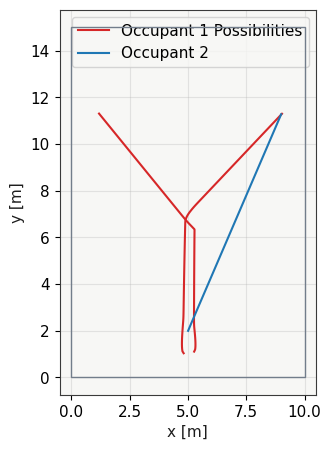

In [14]:
df_2 = result_2.trajectory_dataframe()
initial = df_2[df_2["frame"] == df_2["frame"].min()]
occupant_1_ids = initial[initial["y"] < 1.5]["id"].tolist()
occupant_2_ids = initial[initial["y"] >= 1.5]["id"].tolist()
df_plot = df_2[["id", "frame", "x", "y"]].copy()
df_plot = df_plot[df_plot["id"].isin(occupant_1_ids + occupant_2_ids)]

traj = pedpy.TrajectoryData(
    df_plot[["id", "frame", "x", "y"]].copy(),
    frame_rate=result_2.frame_rate,
)
wa = pedpy.WalkableArea(walkable_2)

fig, ax = plt.subplots()

pedpy.plot_walkable_area(walkable_area=wa, axes=ax)

for agent_id, sub in df_plot.sort_values(["id", "frame"]).groupby("id"):
    if agent_id in occupant_1_ids:
        color = "tab:red"
    else:
        color = "tab:blue"

    ax.plot(sub["x"], sub["y"], color=color)

ax.plot([], [], color="tab:red", label="Occupant 1 Possibilities")
ax.plot([], [], color="tab:blue", label="Occupant 2")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()

## Acceptance - FAIL

In [15]:
assert scenario_2_front["exit_1_count"] == 0
assert scenario_2_front["exit_2_count"] == len(scenario_2_front["rows"])
assert scenario_2_behind["exit_2_fraction"] > run_1a["exit_2_fraction"]

AssertionError: 

The current route assignment is static, so ISO 15 social influence is not reproduced. Model fails the test.